Instrucciones

1. Continuar desde la Parte III
* Asegúrate de tener el repositorio de GitHub clonado localmente y el dataset ya limpiado y preparado desde la Parte III.
2. Análisis Descriptivo y Visualización
* Calcula estadísticas descriptivas básicas para comprender mejor las características de los datos.
* Utiliza histogramas y boxplots para visualizar la distribución de las variables numéricas clave.
* Crea gráficos de líneas para mostrar las tendencias de ventas a lo largo del tiempo.
* Utiliza gráficos de dispersión para analizar la relación entre diferentes variables.
* Combina histogramas y boxplots para visualizar la distribución de las ventas y detectar valores atípicos.
3. Generar un Pull Request en GitHub
* Después de completar el análisis y las visualizaciones, sube los cambios a una nueva rama en tu repositorio de GitHub y genera un Pull Request (PR) para revisión.

Se carga el Dataset limpio de Proyecto I - Parte III

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/content/retail_sales_dataset_limpio.csv')
df

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Tax Amount,Final Price,Sales Normalized,Sales Category,Transaction Rating
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,28.5,178.5,0.063291,Medium,Underperforming❌
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,190.0,1190.0,0.493671,High,Outperforming🔥
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,5.7,35.7,0.002532,Low,Underperforming❌
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,95.0,595.0,0.240506,Medium,Outperforming🔥
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,19.0,119.0,0.037975,Medium,Underperforming❌
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50,9.5,59.5,0.012658,Low,Underperforming❌
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90,17.1,107.1,0.032911,Medium,Underperforming❌
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100,19.0,119.0,0.037975,Medium,Underperforming❌
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150,28.5,178.5,0.063291,Medium,Underperforming❌


In [104]:
# Estadísticas descriptivas columnas relevantes del df
df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].describe()

,Age,Quantity,Price per Unit,Total Amount
count,1000.00000,1000.000000,1000.000000,1000.000000
mean,41.39200,2.514000,179.890000,456.000000
std,13.68143,1.132734,189.681356,559.997632
min,18.00000,1.000000,25.000000,25.000000
25%,29.00000,1.000000,30.000000,60.000000
50%,42.00000,3.000000,50.000000,135.000000
75%,53.00000,4.000000,300.000000,900.000000
max,64.00000,4.000000,500.000000,2000.000000


Se puede observar que la media de columna 'Total Amount' es de 456 dls, pero la mediana es de apenas 135dls. Esto indica en primera instancia que cuando la media es mucho mayor que la mediana, estamos en presencia de una asimetría, lo que implica que la mayoría de las compras son pequeñas, pero hay unas pocas compras muy grandes que elevan el promedio artificialmente. Por otro lado la desv. es mayor que el promedio lo que indica que hay una enorme variabilidad de lo que gasta un cliente y otro. Por último, la edad se distribuye de forma equilibrada entre los 18 y 64 años indicando que no hay un sesgo hacia jóvenes o adultos mayores: el negocio atrae a un público general, no un nicho.

ANÁLISIS DESCRIPTIVO Y VISUALIZACIÓN

Histograma y boxplot para variables numéricas claves

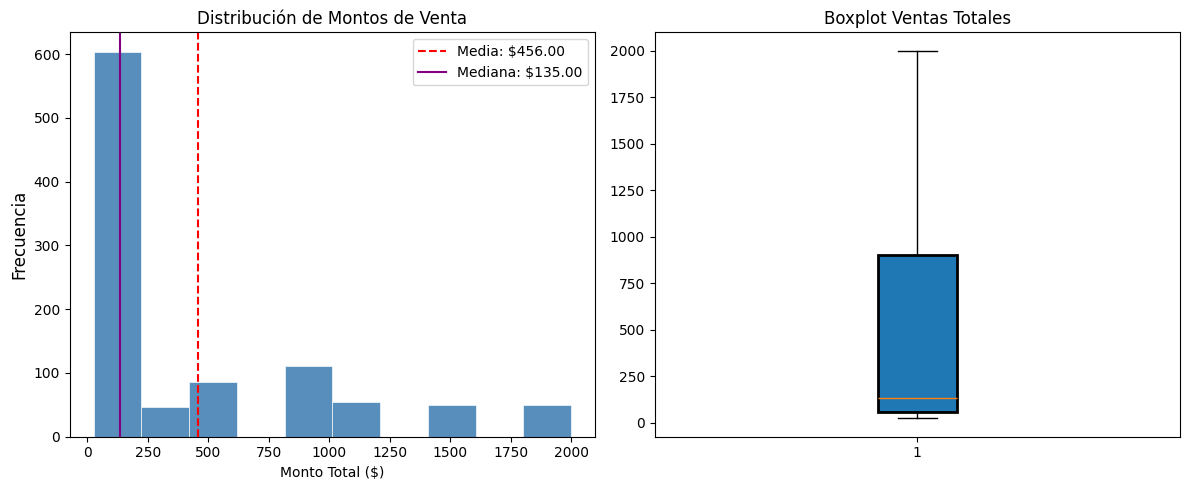

In [105]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Histograma: para ver la distribución de las ventas totales

ax[0].hist(df['Total Amount'], bins=10, color='steelblue', edgecolor='white', alpha=0.9, linewidth=0.5)
ax[0].axvline(df['Total Amount'].mean(),   color='red',  lw=1.5, ls='--', label=f"Media: ${df['Total Amount'].mean():.2f}")
ax[0].axvline(df['Total Amount'].median(),   color='purple',  lw=1.5, ls='-', label=f"Mediana: ${df['Total Amount'].median():.2f}")
ax[0].set_title('Distribución de Montos de Venta', color ='black')
ax[0].set_xlabel('Monto Total ($)')
ax[0].set_ylabel('Frecuencia', fontsize = 12)
ax[0].legend(fontsize=10)



# Boxplot

ax[1].boxplot(df['Total Amount'], patch_artist=True,
            boxprops=dict(color='black', linewidth=2.0))
ax[1].set_title('Boxplot Ventas Totales')
#ax[1].set_ylabel('Dinero ($)', fontsize = 12)

plt.tight_layout()
plt.show()


Del histograma se observa una distribución asimétrica positiva (sesgo hacia la derecha) en los montos de venta, donde la gran mayoría de las transacciones (más de 600) se agrupan en el primer 'bin', por debajo de los 250 aprox. Esto indica que el negocio principal son ventas de bajo ticket. Además, existe una discrepancia notable donde los valores más altos provocan que suba el promedio aunque no representen a la mayoría de clientes. Por último, se presentan sub-picos en los 500, 1000 y 2000 aprox. sugiriendo la existencia de diversos perfiles de clientes o categoría de producto (como por ejemplo los accesorios baratos vs electrónica que se consume a nivel global)


Por otro lado, el boxplot confirma que no hay presencia de outliers: los bigotes de la figura son tan grandes que encierran la totalidad de los datos. No se observa la presencia de ventas atípicas (como errores de digitación o compras institucionales) que logren afectar o distorsionar el promedio. Sin embargo, la caja se encuentra desplazada más hacia abajo, indicando que cerca del 75% de las ventas (Q3) están por debajo de los 900 aprox. y el restante es el que finalmente se dispersa en un rango gigante hasta los 2000.

Gráfico de líneas para visualizar tendencias de ventas a largo plazo

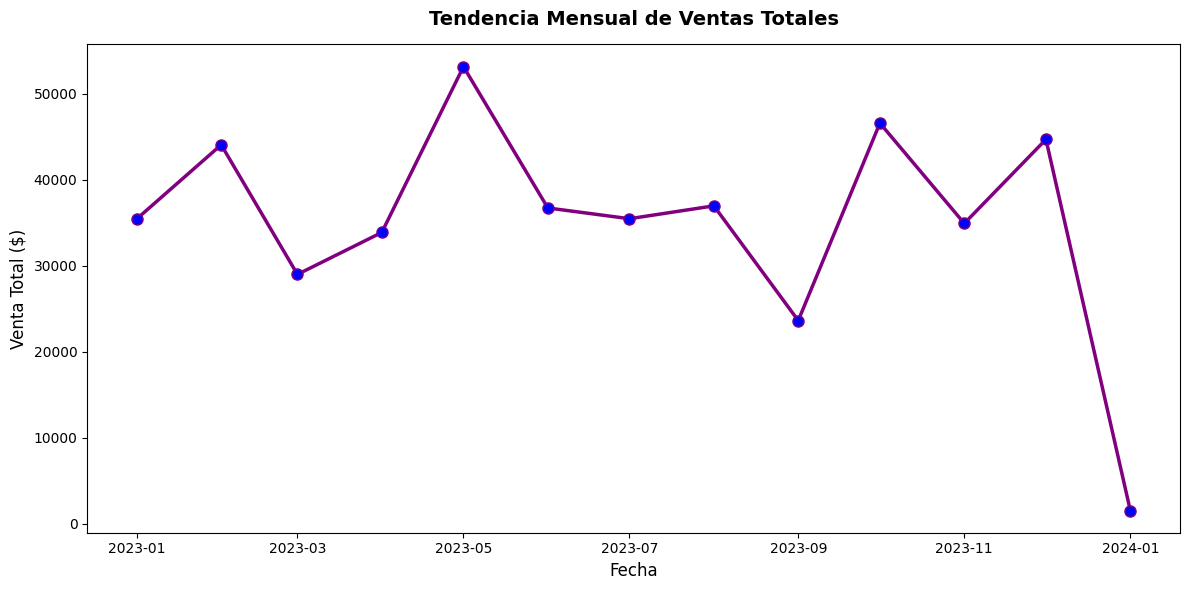

In [106]:
# Primero nos aseguramos que el formato sea fecha y que estén ordenadas por fecha
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

# Se agrupará por mes ya que diario es mucho ruido y arruina el eje 'X'
##DISCLAIMER: el código de la línea inferior fue gracias al uso de IA, una forma rápida de convertir las fechas en meses
ventas_mensuales = df.groupby(df['Date'].dt.to_period('M'))['Total Amount'].sum()

# Y se convierte el índice de vuelta a timestamp para que matplotlib lo entienda
x_eje = ventas_mensuales.index.to_timestamp()   # Las fechas en eje 'X'
y_eje = ventas_mensuales.values   # Venta total mensual en eje 'Y'


# Y con la data modificada se procede a graficar
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(x_eje, y_eje, color='purple', linewidth=2.5,
        marker="o", markersize=8, markerfacecolor='blue')

ax.set_title('Tendencia Mensual de Ventas Totales', fontsize=14, fontweight="bold", pad=14)
ax.set_xlabel("Fecha", fontsize=12)
ax.set_ylabel("Venta Total ($)", fontsize=12)


plt.tight_layout()
plt.show()

El gráfico muestra claramente que las ventas no son constantes, sino que presentan cierta volatilidad.

Se observa un máximo histórico en mayo del 2023. Esto sugiere una fuerte estacionalidad quizás campaña de marketing u otras opciones a barajar. La caída estrepitosa entre mayo y junio, o el repunte de octubre, indican un negocio sensible a eventos externos. El último punto presenta una caída fuerte probablemente por un corte de datos, ya que el dataset termina en los primeros días de enero, y que no se deba a un colapso del negocio.

Todo lo anterior podría sugerir que el negocio analizado depende de ciclos promocionales.

Gráfico de dispersión para visualizar si existe relación de gastos en hombres y mujeres según su edad

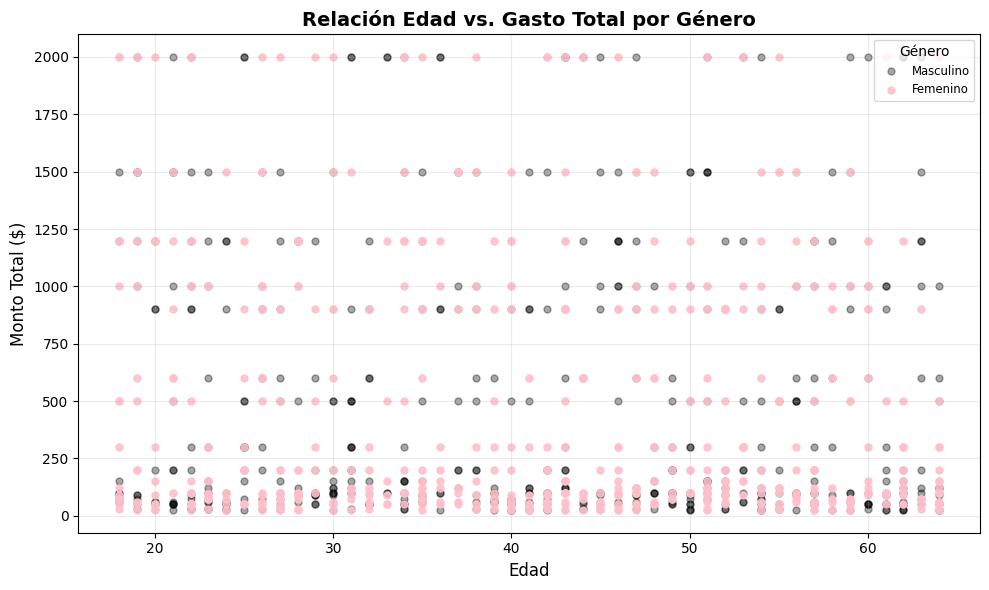

In [107]:
# Gráfico de dispersión: nos dirá cómo gastan los hombres vs las mujeres en relación a su edad
fig, ax = plt.subplots(figsize=(10, 6))

hombres = df[df['Gender'] == 'Male']
mujeres = df[df['Gender'] == 'Female']

ax.scatter(hombres['Age'], hombres['Total Amount'], alpha=0.35, color='black', label='Masculino', s=25)

ax.scatter(mujeres['Age'], mujeres['Total Amount'],
           alpha=0.9, color='pink', label='Femenino', s=100, marker=".")

ax.set_title('Relación Edad vs. Gasto Total por Género', fontsize=14, fontweight="bold")


ax.set_xlabel('Edad', fontsize=12)
ax.set_ylabel('Monto Total ($)', fontsize=12)
ax.legend(loc='upper right', fontsize='small', title='Género')
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

Al cruzar la edad con el gasto, notamos que no existe una correlación, es una distribución dispersa y uniforme, lo que significa que la edad no es un factor relacionado con el gasto total: un cliente de 30 años tiene la misma probabilidad de gastar 500 dls que alguien de 50 años. Por otro lado, al separar por género, se aprecia que ambos grupos se solapan en todos los niveles de precio y edad. Este gráfico de dispersión es fundamental para validar que no existe un sesgo demográfico según el comportamiento de compra y las franjas están estructuradas horizontalmente debido probablemente a los precios fijos del dataset, por eso los puntos se alinean en esos montos sin importar la edad del comprador.
